# Global Cancer Healthcare Analytics - EDA & Predictive Modeling

**Analyzing Cancer Risk Factors to evaluate Severity and Survival outcomes using Data Analytics and Machine Learning**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load File "global_cancer_patients_2015_2024" 
health= pd.read_csv(r"C:\Users\Mohd Junaid\Downloads\global_cancer_patients_2015_2024 (1).csv")

In [3]:
#Data Overview
health.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [4]:
#Overview of Data structure and dtypes 
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [5]:
health.duplicated().sum()
#Data has no null values , no duplicate values and no messy data which is now ideal for analysis. 

np.int64(0)

# Exploratory Data Analysis (EDA)

**Statistical summary of Age**

In [6]:
health['Age'].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

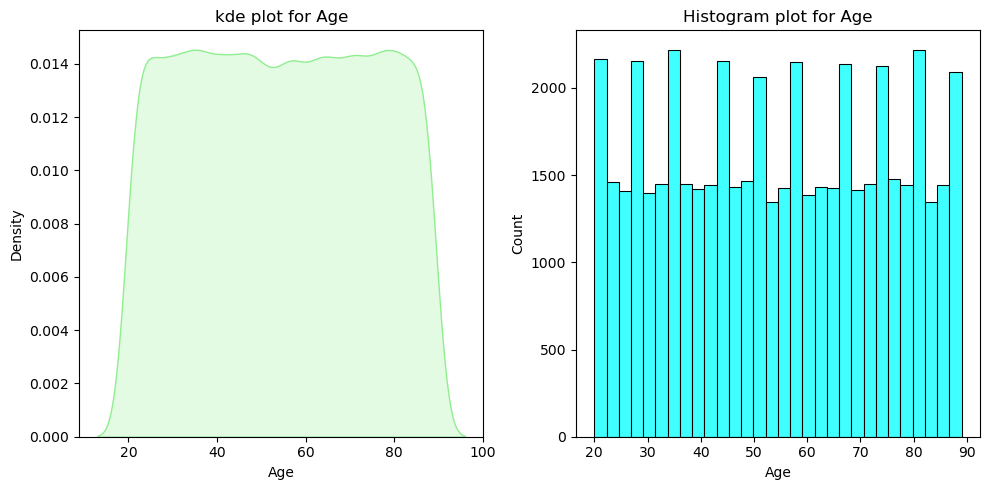

In [9]:
#Visualization of Age through Histogram and KDE

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.kdeplot(data=health['Age'],fill= True, color= 'lightgreen')
plt.title("kde plot for Age")

plt.subplot(1,2,2)
sns.histplot(data=health['Age'], bins= 30, kde= False, color= 'cyan')
plt.title("Histogram plot for Age")

plt.tight_layout()
plt.show


**Gender Analysis**

In [9]:
health['Gender'].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

Text(0, 0.5, 'Count')

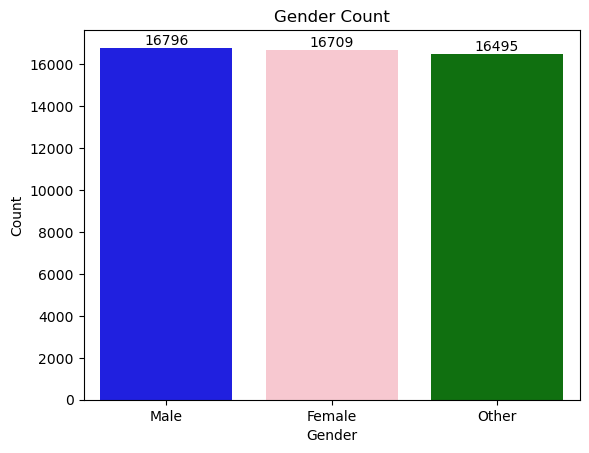

In [10]:
#Gender visualization through Barplot
sns.barplot(x= health['Gender'].value_counts().index, y= health['Gender'].value_counts().values, 
            palette= ['blue', 'pink','green'])

for i,v in enumerate(health['Gender'].value_counts()):
    plt.text(i,v, str(v), ha= 'center', va= 'bottom')

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")




**Country_Region Analysis**

In [6]:
health['Country_Region'].value_counts()

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

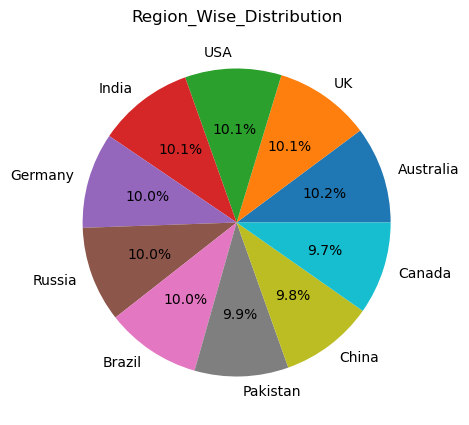

In [16]:
#Country_Region wise visualization
country_t= health['Country_Region'].value_counts()

plt.figure(figsize= [5,5])
plt.pie(x= country_t.values,
        labels= country_t.index,
        autopct= '%1.1f%%'
       )

plt.title('Region_Wise_Distribution')
plt.show()


**Cancer_type analysis**

In [7]:
health['Cancer_Type'].value_counts()

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

Text(0, 0.5, 'Counts')

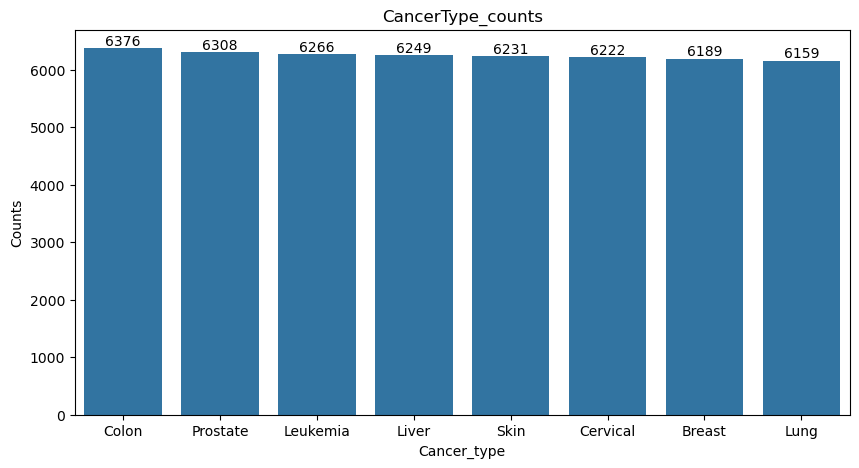

In [73]:
#Cancer_type visualization(category)

plt.figure(figsize=[10,5])
sns.barplot(x= health['Cancer_Type'].value_counts().index, y= health['Cancer_Type'].value_counts().values)

for i,v in enumerate(health['Cancer_Type'].value_counts()):
    plt.text(i,v, str(v), ha= 'center', va= 'bottom')

plt.title("CancerType_counts")
plt.xlabel("Cancer_type")
plt.ylabel("Counts")

**Cancer_Stage analysis**

In [8]:
health['Cancer_Stage'].value_counts()

Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64

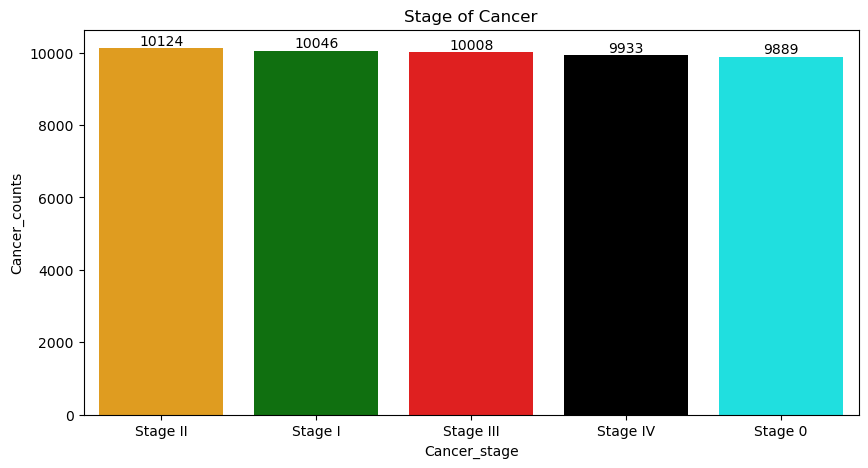

In [22]:
#Cancer_Stage's visualization
plt.figure(figsize= [10,5])
sns.barplot(x=health['Cancer_Stage'].value_counts().index,
            y=health['Cancer_Stage'].value_counts().values,
            palette= ['orange', 'green', 'red', 'black', 'cyan'])

for i, v in enumerate(health['Cancer_Stage'].value_counts()):
    plt.text(i,v, str(v), ha= 'center', va='bottom')

plt.title('Stage of Cancer')
plt.xlabel('Cancer_stage')
plt.ylabel('Cancer_counts')
plt.show()

            

**Treatment_Cost_USD_ analysis(numerical)**

In [9]:
health['Treatment_Cost_USD'].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

In [20]:
#About Skewness

round(health['Treatment_Cost_USD'].skew(),4).item()


0.0041

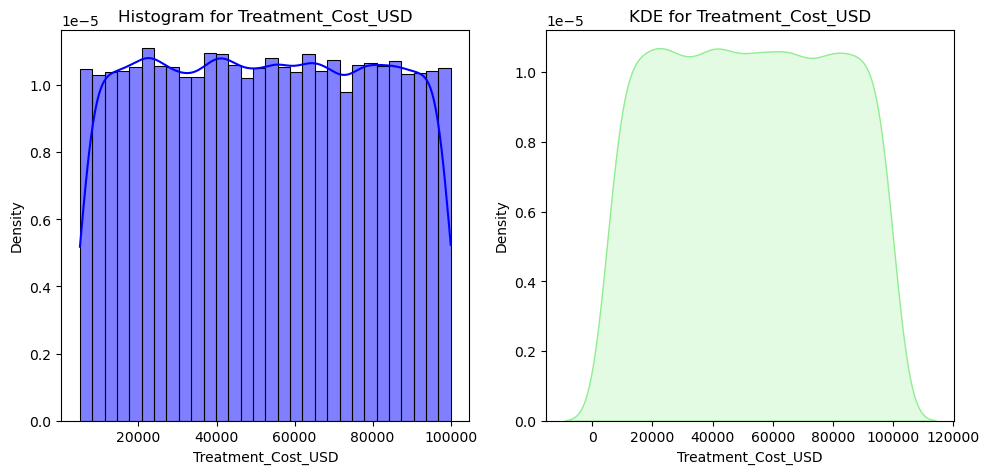

In [35]:
#plotting for Treatment_Cost_USD

plt.figure(figsize=[10,5])

plt.subplot(1,2,2)
sns.kdeplot(health['Treatment_Cost_USD'], fill=True, color= 'lightgreen', bw_adjust=1.5)
plt.title("KDE for Treatment_Cost_USD")

plt.subplot(1,2,1)
sns.histplot(health['Treatment_Cost_USD'], bins= 30, color= 'blue', edgecolor= 'black', stat='density', kde= True)
plt.title("Histogram for Treatment_Cost_USD")

plt.tight_layout()
plt.show()




**Analysis of risk factors(independent Variable)**

In [12]:
health.columns
risk_factors= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Treatment_Cost_USD']
summary= health[risk_factors].agg(['mean', 'std','min','max']).T
summary

,mean,std,min,max
Genetic_Risk,5.001698,2.885773,0.00,10.00
Air_Pollution,5.010126,2.888399,0.00,10.00
Alcohol_Use,5.010880,2.888769,0.00,10.00
Smoking,4.989826,2.881579,0.00,10.00
Obesity_Level,4.991176,2.894504,0.00,10.00
Treatment_Cost_USD,52467.298239,27363.229379,5000.05,99999.84


# Statistical & Inferential Analysis

**Determine the relationship between risk factors and cancer severity.**

<function matplotlib.pyplot.show(close=None, block=None)>

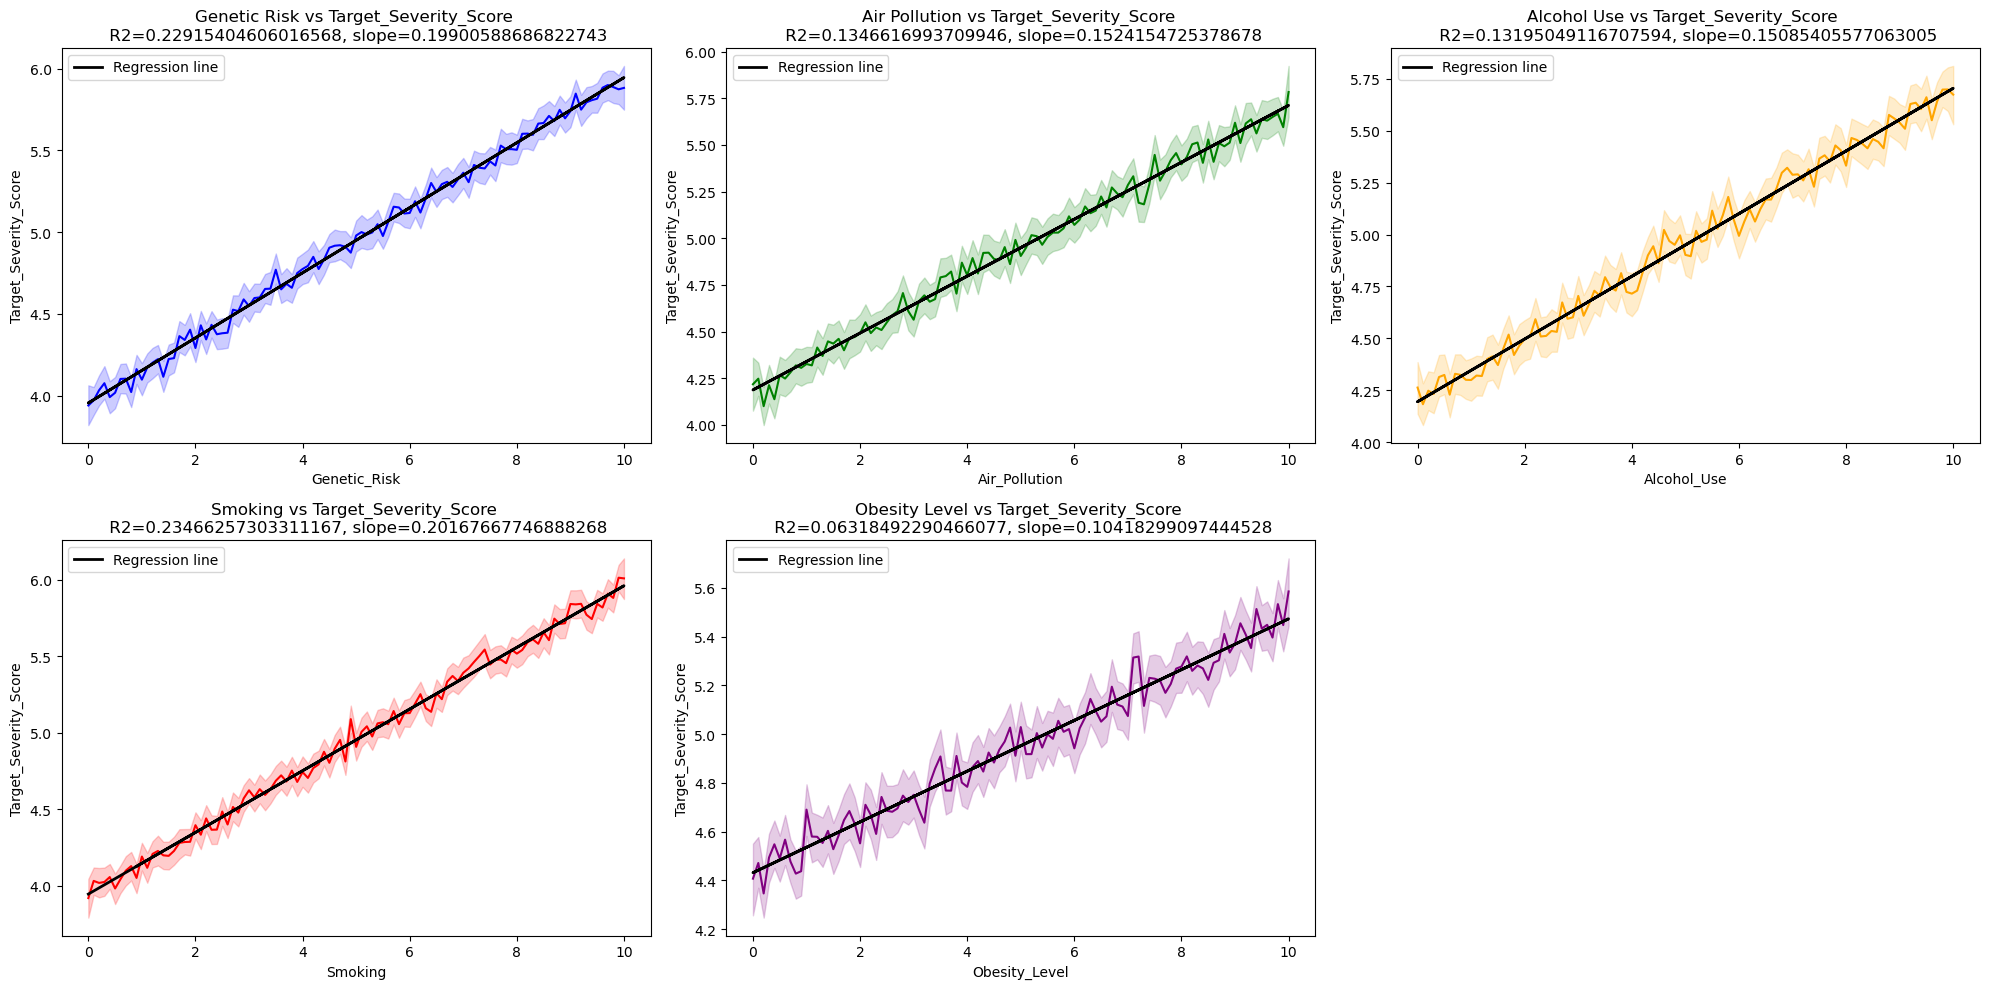

In [7]:
from scipy.stats import linregress

risk_factors= ['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
titles= ['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors= ["blue", "green", "orange", "red", "purple"]

plt.figure(figsize=[20,10])
for i, (factor, title, color) in enumerate(zip(risk_factors, titles, colors), start=1):
    plt.subplot(2,3,i)

    x=health[factor]
    y= health['Target_Severity_Score']
    slope, intercept, r_value, p_value, std_err= linregress(x,y)
    r_squared= r_value**2

    sns.lineplot(x= factor , y='Target_Severity_Score', data=health, color= color)
    plt.plot(x,slope*x+intercept, linewidth=2, label= "Regression line", color='black')
    plt.title(f"{title} vs Target_Severity_Score \n R2={ r_squared}, slope={slope}")
    plt.xlabel(factor)
    plt.ylabel('Target_Severity_Score')
    plt.legend()


    
plt.tight_layout()
plt.show()
    




**To understand the contribution of various risk factors to cancer severity, line plots were generated for five primary variables:**  *Genetic Risk, Air Pollution, Alcohol Use, Smoking, and Obesity Level, plotted against the Target Severity Score.*

**All graphs reveal a positive relationship, indicating that as the level of a particular risk factor increases, the corresponding severity of the condition also tends to rise. However, the degree of association—measured by the slope and tightness of the confidence interval—varies across factors.**

**Genetic Risk vs Target Severity Score**
R² = 0.23: A weak linear relationship. Only 23% of the variation in the target score is explained by Genetic Risk.
Slope = 0.20: A positive slope indicates that as Genetic_Risk increases, the Target_Severity_Score also tends to increase. 

**Air Pollution vs Target Severity**
R² = 0.13: A very weak relationship. Only 13% of the variation in the target score is explained Air Pollution.
Slope = 0.15:
A positive slope means that as air pollution increases, the severity score slightly increases. 

**Alcohol Use vs Target Severity Score**
R² = 0.13:
Similarly, the relationship between Alcohol_Use and Target_Severity_Score is also weak. Only 13% of the variation in the target score is explained by alcohol use.
Slope = 0.15:
The positive slope indicates that increased alcohol use correlates with a slight increase in target severity. 

**Smoking vs Target Severity Score**
R² = 0.23:
A weak relationship, similar to Genetic_Risk. Smoking explains only 23% of the variance in the target score, leaving the majority of the variation to be explained by other factors.
Slope = 0.20:
The positive slope implies that as smoking increases, the target severity score increases as well. 

**Obesity Level vs Target Severity Score**
R² = 0.06:
The weakest relationship among all factors. Only 6% of the variation in the target score is explained by obesity level, suggesting that obesity has a minimal effect on the target variable.
Slope = 0.10:
A positive slope, indicating a slight increase in the severity score as obesity level increases. However, due to the very low R², this is a weak and unreliable relationship.


**Analyze the proportion of early-stage diagnoses by cancer type?**

In [13]:
#Unique colums name
health['Cancer_Type'].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [8]:
#Diagnosis of Lung in early stage percentage
count_stages=health[health['Cancer_Type']== 'Lung']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of lung cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of lung cancer diagnosed at early stage 0 and stage I: 38.43


In [9]:
#Diagnosis of Leukemia in early stage percentage
count_stages=health[health['Cancer_Type']== 'Leukemia']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Leukemia cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Leukemia cancer diagnosed at early stage 0 and stage I: 39.53


In [10]:
#Diagnosis of Breast in early stage percentage
count_stages=health[health['Cancer_Type']== 'Breast']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Breast cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Breast cancer diagnosed at early stage 0 and stage I: 39.47


In [11]:
#Diagnosis of Colon in early stage percentage
count_stages=health[health['Cancer_Type']== 'Colon']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Colon cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Colon cancer diagnosed at early stage 0 and stage I: 40.42


In [12]:
#Diagnosis of Skin in early stage percentage
count_stages=health[health['Cancer_Type']== 'Skin']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Skin cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Skin cancer diagnosed at early stage 0 and stage I: 40.41


In [13]:
#Diagnosis of Cervical in early stage percentage
count_stages=health[health['Cancer_Type']== 'Cervical']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Cervical cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Cervical cancer diagnosed at early stage 0 and stage I: 39.86


In [14]:
#Diagnosis of Prostate in early stage percentage
count_stages=health[health['Cancer_Type']== 'Prostate']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
prop= round(proportion, ndigits=2)
print(f"Proportion of Prostate cancer diagnosed at early stage 0 and stage I: {prop}")

Proportion of Prostate cancer diagnosed at early stage 0 and stage I: 40.19


In [15]:
#Diagnosis of Liver in early stage percentage
count_stages=health[health['Cancer_Type']== 'Liver']['Cancer_Stage'].value_counts()	
early_stage= count_stages.get('Stage 0',0)+count_stages.get('Stage I',0)
Total_count_stages= count_stages.sum()
proportion= (early_stage/Total_count_stages)*100
print(f"Proportion of Liver cancer diagnosed at early stage 0 and stage I: {proportion}")

Proportion of Liver cancer diagnosed at early stage 0 and stage I: 40.614498319731155


Above analysis show that early-stage diagnosis for various cancer types is relatively widespread, with most cancers having an early diagnosis rate between 38.43% and 40.61%. Liver Cancer shows the highest proportion, while Lung Cancer shows the lowest. These findings suggest that while screening and diagnostic methods are effective, improvements can still be made, particularly in lung cancer detection.


**Identify key predictors of cancer severity and survival years through "Karl Pearson and Spearman".**

In [16]:
#Independent variable and dependent variable
features= ['Age', 'Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
targets= ['Survival_Years', 'Target_Severity_Score']

#calculate correlation
pearson_corr= health[features+targets].corr(method='pearson')
spearman_corr= health[features+targets].corr(method='spearman')

#slice out insight that only relationship with target variables
pearson_result= pearson_corr[targets]
spearman_result= spearman_corr[targets]

#Combine both correlation
correlation_data= pd.concat([pearson_result, spearman_result], axis=1, keys=["Pearson","Spearman"])
correlation_data

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

# Predictive Analytics & Machine Learning

**_Key Identifier predictors of cancer severity through machine learning pipeline_**

In [14]:
# random forest for target severity score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [20]:
#converting categorical columns into numerical
catergorical_cols= ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
for cols in catergorical_cols:
    le= LabelEncoder()
    health[cols]=le.fit_transform(health[cols])


# Preparing  features and target
x= health.drop(columns= ['Patient_ID', 'Survival_Years', 'Target_Severity_Score','Treatment_Cost_USD'])
y_severity= health['Target_Severity_Score']

# Train-test split
X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(x,y_severity,  test_size= 0.2, random_state=40)

# Train the model
model=RandomForestRegressor(n_estimators= 200, max_depth= None, min_samples_split=2, min_samples_leaf=1, random_state= 40)
model.fit(X_train_s, Y_train_s)

# Evalaute
train_r2_severity= r2_score(Y_train_s, model.predict(X_train_s))
test_r2_severity= r2_score(Y_test_s, model.predict(X_test_s))






In [21]:
print(train_r2_severity)
print(test_r2_severity)


0.9689503792116058
0.7752278237418935


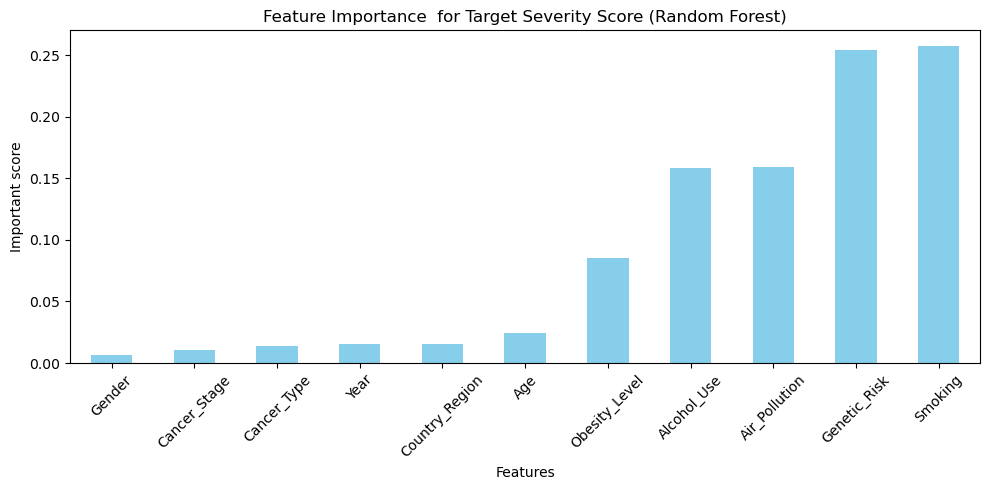

In [23]:
feature_importance_sevrity= pd.Series(model.feature_importances_, index= x.columns).sort_values(ascending= True)

#plotting of important features
plt.figure(figsize= [10,5])
feature_importance_sevrity.plot(kind= 'bar', color='skyblue')
plt.title("Feature Importance  for Target Severity Score (Random Forest)")
plt.xlabel('Features')
plt.ylabel('Important score')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()
           

**Feature	Importance	Interpretation**
*Smoking	0.2336 most important predictor of severity score. The more a patient smokes, the higher their severity tends to be.*

**Genetic_Risk 0.2286**	*Strong genetic predisposition is nearly as important as smoking.*

**Treatment_Cost_USD 0.2133** *Higher treatment costs are associated with more severe conditions.*

**Alcohol_Use 0.1291** *Alcohol also plays a significant role.*

**Air_Pollution 0.1271** *Environmental factor—patients in more polluted areas have worse severity scores.*

**Obesity_Level	0.0573** *Has an effect, but much smaller.*

**Age to Gender	< 0.01** *Very low importance; these don’t explain much variation in severity score.*

**E.g., Smoking, Genetic Risk, AIr plollution are major influencers. These tells us if these is control on these factors that might reduce severity.**


# Check whether these risk-factors influence on Survival_Years apart from Target_Severity_Score.


In [6]:
health.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [9]:

# conveting categorical columns to numerical columns
categorical_cols= ["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_cols:
    le= LabelEncoder()
    health[col]=le.fit_transform(health[col])

# Preparing  features and input
X= health.drop(columns=["Patient_ID","Survival_Years","Target_Severity_Score","Treatment_Cost_USD"])
y_severity= health["Survival_Years"]

# train test split
X_train_s, X_test_s, y_train_s, y_test_s= train_test_split(X, y_severity, test_size=0.2, random_state=40)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}




In [11]:
# train the model
model= RandomForestRegressor(random_state=40)
GSC= GridSearchCV(model , param_grid, cv=3, scoring="r2", n_jobs=-1)
GSC.fit(X_train_s, y_train_s)

best_rf_severity= GSC.best_estimator_

# evalaute the model
train_r2_severity= r2_score(y_train_s , best_rf_severity.predict(X_train_s))
test_r2_severity= r2_score(y_test_s , best_rf_severity.predict(X_test_s))

In [12]:
print(train_r2_severity)
print(test_r2_severity)

0.008998065861791527
-0.0003487352301700941


# Explore the economic burden of cancer treatment across different demographics and countries

In [15]:
health= pd.read_csv(r"C:\Users\Mohd Junaid\Downloads\global_cancer_patients_2015_2024 (1).csv")

In [16]:
health.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [18]:
health['Age_group']=pd.cut(health['Age'], bins=[0,30,45,60,75,90], labels=['0-30', '31-45','46-60','61-75','76+'])

In [19]:
health.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45


In [32]:
country_age_cost=health.groupby(['Age_group', 'Age','Country_Region','Gender'], observed= False)['Treatment_Cost_USD'].mean().reset_index()

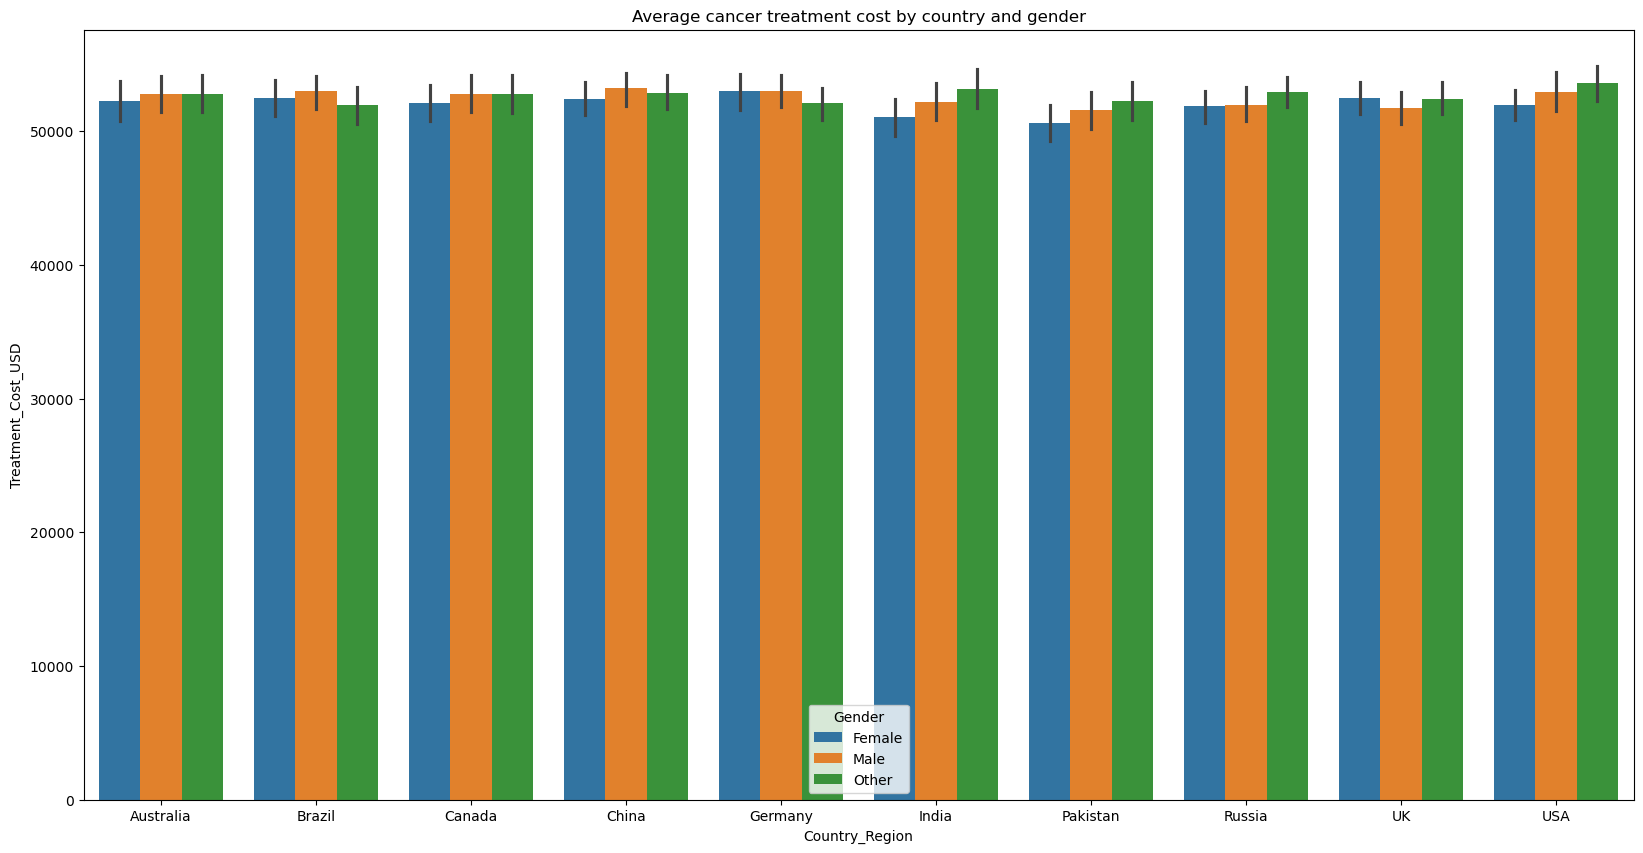

In [33]:
plt.figure(figsize=(20,10))
sns.barplot(data=country_age_cost, x='Country_Region', y='Treatment_Cost_USD', hue='Gender')
plt.title("Average cancer treatment cost by country and gender")
plt.show()

In [39]:
# Check with the heatmap
country_age_cost=health.groupby(['Age_group', 'Age','Country_Region','Gender'], observed= False)['Treatment_Cost_USD'].mean().reset_index()
health_heatmap=country_age_cost.pivot_table(index='Age_group', columns='Country_Region', values= 'Treatment_Cost_USD', aggfunc='mean')

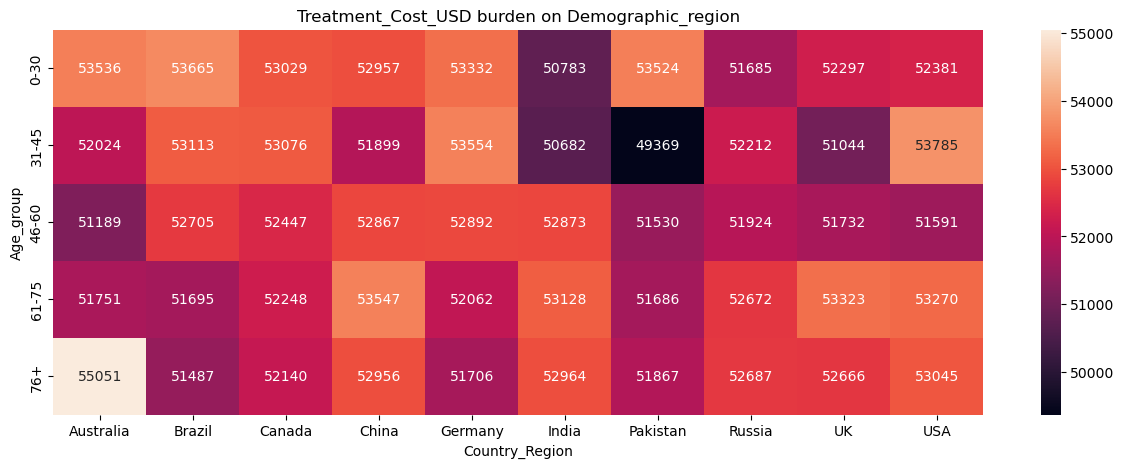

In [41]:
plt.figure(figsize=(15,5))
sns.heatmap(data=health_heatmap, annot=True, fmt='0.0f')
plt.title("Treatment_Cost_USD burden on Demographic_region")
plt.show()

**_Geographic Disparities in Economic Burden:_**
*Cancer treatment costs are significantly higher in developed nations such as the USA, Australia, and China, revealing the heavy financial load in advanced healthcare systems. 
Meanwhile, countries like India and Pakistan exhibit comparatively lower costs, likely due to lower healthcare pricing structures or limited access to advanced treatment. 
People’s financial burden depends a lot on the country they live in. Some countries make treatment very expensive, while others are more affordable.*

**_Gender-Based Cost Patterns are Uniform:_**
*The analysis shows that treatment costs for males and females are nearly equal in most countries.
This means:
there is no major difference in pricing between genders,
both men and women face similar financial pressure during cancer treatment.*

**_Older People Usually Pay More for Treatment:_**
*As age increases, treatment costs also increase, especially for people aged 61 years and above.
This is more noticeable in countries like:Australia, United States.
Senior citizens face higher medical expenses and need more financial support*

**_Strong Healthcare Systems Help Reduce Cost Differences:_**
*Countries such as:Canada, Germany, United Kingdom have better public healthcare systems because of government support and insurance coverage:
So, it can be say that Government healthcare support can reduce financial stress for cancer patients.*
    

    

# Overall Conclusion
**The study shows that:**
1. Cancer treatment can become a major financial burden.

2. Costs depend strongly on country and age.

3. Gender has very little effect on treatment cost.

4. Strong public healthcare systems help make treatment more affordable and fair for patients.


   




# Potential future enhancements include:
**Survival prediction models**

**Real-time healthcare analytics**

**Power BI integration**

**SQL database integration**


# END